In [1]:
from scipy.stats import norm
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

### **Критерий Пирсона для непрерывных распределений**

Попробуем применить один и тот же тест для разного разбиения

In [4]:
np.random.seed(0)
n = 1000
sample = norm.rvs(loc=0.05, scale=1, size=n)

По выборке хотим проверить гипотезу
$$H_0: X \sim N(0, 1)$$

In [6]:
# 1) bins = 10

In [7]:
observed_freq_1, bins_1 = np.histogram(sample, bins=10)
print(observed_freq_1, bins_1)

[  9  20  70 146 217 239 160  86  38  15] [-2.99614305 -2.41559324 -1.83504342 -1.2544936  -0.67394379 -0.09339397
  0.48715585  1.06770566  1.64825548  2.2288053   2.80935511]


In [8]:
probs_1 = [norm.cdf(bins_1[i+1])-norm.cdf(bins_1[i]) for i in range(1, len(observed_freq_1)-1)]
probs_1.insert(0, norm.cdf(bins_1[1]))
probs_1.insert(-1, 1-norm.cdf(bins_1[-2]))
sum(probs_1)

1.0

In [9]:
exp_freq_1 = n*np.array(probs_1) # n*p^0_i
# exp_freq_1 

In [10]:
chi2_1 = stats.chisquare(observed_freq_1, exp_freq_1)
chi2_1

Power_divergenceResult(statistic=65.19345152770751, pvalue=1.3229632028268077e-10)

In [11]:
# 2) bins = 15

In [12]:
observed_freq_2, bins_2 = np.histogram(sample, bins=15)

In [13]:
probs_2 = [norm.cdf(bins_2[i+1])-norm.cdf(bins_2[i]) for i in range(1, len(observed_freq_2)-1)]
probs_2.insert(0, norm.cdf(bins_2[1]))
probs_2.insert(-1, 1-norm.cdf(bins_2[-2]))
sum(probs_2)

1.0

In [14]:
exp_freq_2 = n*np.array(probs_2)
# exp_freq_2

In [15]:
chi2_2 = stats.chisquare(observed_freq_2, exp_freq_2)
chi2_2

Power_divergenceResult(statistic=18.141023751963527, pvalue=0.20043317086725415)

**Результат:** для одной и той же выборки из непрерывного распределения, критерий Пирсона дает разные результаты при разных разбиениях.
<br />
**Нужен другой тест для непрерывных распределений**

### **Критерий Колмогорова**

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

Пусть имеется выборка $X_1, ..., X_n \overset{iid}{\sim} F_X(x)$. Хотим проверить гипотезу
$$H_0: F_X(x) = F_0(x)$$
$$H_1: F_X(x) \neq F_0(x)$$

In [20]:
from yahooquery import Ticker
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [21]:
cola = Ticker('KO')
cola_data = cola.history(start = '2010-01-01', end = '2022-01-01', interval = '1d')
prices_cola = cola_data['close']
prices_cola = pd.DataFrame(prices_cola)

r_cola = (prices_cola.close.diff()/prices_cola.close.shift(1)).dropna()
r_cola

symbol  date      
KO      2010-01-05   -0.012097
        2010-01-06   -0.000355
        2010-01-07   -0.002485
        2010-01-08   -0.018509
        2010-01-11    0.020308
                        ...   
        2021-12-27    0.007386
        2021-12-28    0.003922
        2021-12-29    0.001189
        2021-12-30   -0.002884
        2021-12-31    0.007315
Name: close, Length: 3020, dtype: float64

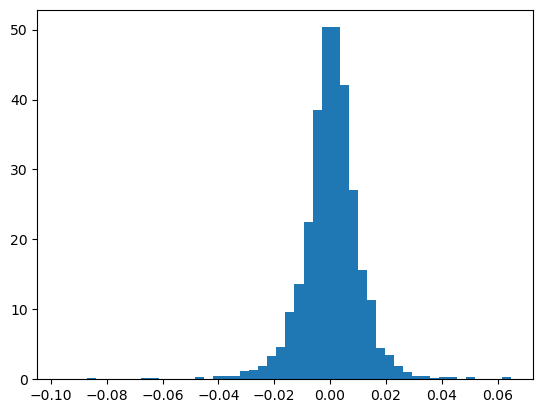

In [22]:
plt.hist(r_cola, bins=50, density=True)
plt.show()

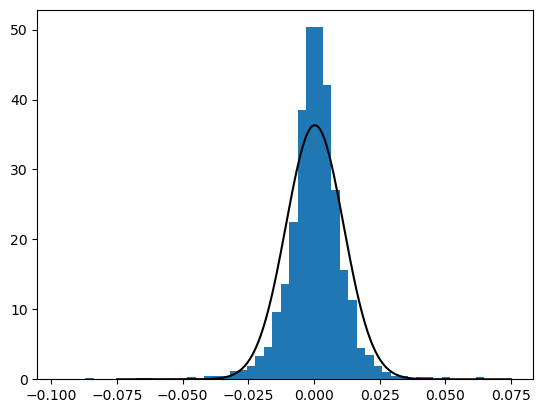

In [23]:
plt.hist(r_cola, bins=50, density=True)

xs = np.linspace(-0.075, 0.075, 300)
ys = stats.norm(loc=r_cola.mean(), scale=r_cola.std(ddof=1)).pdf(xs)
plt.plot(xs, ys, color='black')

**Теорема Колмогорова.** Если $F(x)$ - непрерывная, то распределение случайной величины $$D_n = \underset{x \in R}{sup}|\hat{F}_n(x)-F(x)|$$
не зависит от $F(x)$. Более того, $$\sqrt{n}D_n \xrightarrow{\text{d}} K(x),$$ где $K(x)$ - *рапределение Колмогорова* с функцией распределения $K(y)=\underset{k \in Z}{\Sigma} (-1)^k e^{-2k^2y^2}$.

Пусть имеется выборка $X_1, ..., X_n \overset{iid}{\sim} F_X(x)$. Хотим проверить гипотезу
$$H_0: F_X(x) = F_0(x)$$
$$H_1: F_X(x) \neq F_0(x)$$
Из *теоремы Колмогорова*
$$K_{st} = \sqrt{n} \underset{x \in R}{sup}|\hat{F}_n(x)-F_0(x)| \overset{H_0}{\sim} K(x),$$ где $K(x)$ - распределение Колмогорова.
$$RR = \{K_{st} > K_{1-\alpha}\}.$$

In [26]:
stats.kstest(r_cola, 'norm', args=(r_cola.mean(), r_cola.std(ddof=1)))

KstestResult(statistic=0.07955633807157095, pvalue=4.501406646635216e-17, statistic_location=-0.0061881031331112975, statistic_sign=-1)

### **Критерий однородности Смирнова**

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html

**Теорема Смирнова.** Если функция распределения выборок $F(x)$ - непрерывная, то распределение случайной величины $$D_{n,m} = \underset{x \in R}{sup}|\hat{F}_n(x)-\hat{F}_m(x)|$$
зависит только от $m, n$. Более того, $$\sqrt{\frac{nm}{n+m}}D_{n,m} \xrightarrow{\text{d}} K(x)$$ при $n, m \rightarrow \infty$, где $K(x)$ - *рапределение Колмогорова*.

Пусть имеется две выборки $X_1, ..., X_n \overset{iid}{\sim} F_X(x)$ и $Y_1, ..., Y_m \overset{iid}{\sim} F_Y(x)$. Хотим проверить гипотезу
$$H_0: F_X(x) = F_Y(x)$$
$$H_1: F_X(x) \neq F_Y(x)$$
Из *теоремы Смирнова*
$$K_{st} = \sqrt{\frac{nm}{n+m}} \underset{x \in R}{sup}|\hat{F}_n(x)-\hat{F}_m(x)| \overset{H_0}{\sim} K(x),$$ где $K(x)$ - распределение Колмогорова.
$$RR = \{K_{st} > K_{1-\alpha}\}.$$

In [31]:
apple = Ticker('AAPL')
apple_data = apple.history(start = '2014-01-01', end = '2024-01-01', interval = '1d')
prices_apple = apple_data['close']
prices_apple = pd.DataFrame(prices_apple)

r_apple = (prices_apple.close.diff()/prices_apple.close.shift(1)).dropna()

In [32]:
stats.ks_2samp(r_cola, r_apple)

KstestResult(statistic=0.12974076073361157, pvalue=1.3656328360879696e-20, statistic_location=0.007647823964638091, statistic_sign=1)